# Testeo y Evaluación de YOLO OBB (Oriented Bounding Boxes)

Este notebook permite cargar el mejor modelo entrenado (`best.pt`) y evaluar sus métricas en el conjunto de validación y testeo, además de visualizar predicciones de cajas orientadas (rotadas).

### 1. Instalación de Dependencias y Configuración
Instalamos la librería de Ultralytics (YOLO) y otras dependencias necesarias si es que no están instaladas, y definimos el directorio del dataset.

In [1]:
%pip install ultralytics roboflow matplotlib opencv-python numpy pyyaml

import os
import glob
import random
from ultralytics import YOLO
from IPython.display import Image, display


EXTRACT_DIR = "./dataset_obb"

Note: you may need to restart the kernel to use updated packages.


### 2. Validar el Modelo
Una vez completado el entrenamiento, podemos validar las métricas obtenidas con el mejor modelo guardado.

In [2]:
# Buscar dinámicamente el archivo best.pt para evitar errores de rutas de Ultralytics
best_weights = glob.glob('**/weights/best.pt', recursive=True)

if best_weights:
    best_path = best_weights[0]
    print(f"Cargando mejor modelo desde: {best_path}")
    best_model = YOLO(best_path)
    # Validar
    metrics = best_model.val()
    print("Métricas de validación calculadas con éxito.\n")

    print("Métricas Generales (Cajas Orientadas - OBB)")
    print(f"Precisión media (mAP50):      {metrics.box.map50:.4f}")
    print(f"Precisión media (mAP50-95):   {metrics.box.map:.4f}")
    print(f"Precisión (Precision):        {metrics.box.mp:.4f}")
    print(f"Exhaustividad (Recall):       {metrics.box.mr:.4f}\n")

    # Mostrar métricas por clase
    print("Métricas por Clase")
    names = best_model.names
    for i, class_name in names.items():
        ap50 = metrics.box.ap50[i]
        ap = metrics.box.ap[i]
        p = metrics.box.p[i]
        r = metrics.box.r[i]
        print(f"Clase {i} ({class_name}):")
        print(f"  mAP50:      {ap50:.4f}")
        print(f"  mAP50-95:   {ap:.4f}")
        print(f"  Precision:  {p:.4f}")
        print(f"  Recall:     {r:.4f}\n")
else:
    print("ERROR: No se encontró el archivo best.pt. Asegúrate de haber completado el entrenamiento.")

Cargando mejor modelo desde: runs/runs/tenis_mesa_obb_run/weights/best.pt
Ultralytics 8.4.75 🚀 Python-3.12.11 torch-2.8.0+cu128 CUDA:0 (NVIDIA L40S, 45458MiB)
YOLO26m-obb summary (fused): 142 layers, 21,200,216 parameters, 0 gradients, 71.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1533.4±572.4 MB/s, size: 35.0 KB)
val: Scanning /teamspace/studios/this_studio/table-tennis-cv/data/dataset_obb/valid/labels.cache... 55 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 13.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.4it/s 1.7s0.7s
                   all         55        163      0.884      0.716      0.782      0.616
                TT Net         43         46      0.875      0.913      0.935       0.76
             TT Racket         45         72      0.963      0.569      0.651      0.468
              TT Table         40         45      0.813      0.667      0.759       0.62
Speed: 

### 3. Visualizar Métricas y Gráficos del Entrenamiento
YOLO genera automáticamente gráficos con el progreso de las pérdidas (losses) y las precisiones (mAP50, mAP50-95) a lo largo de las épocas, así como la matriz de confusión.

Cargando resultados de la carpeta: runs/runs/tenis_mesa_obb_run/
Curvas de Pérdidas y Métricas (mAP50 / mAP50-95)


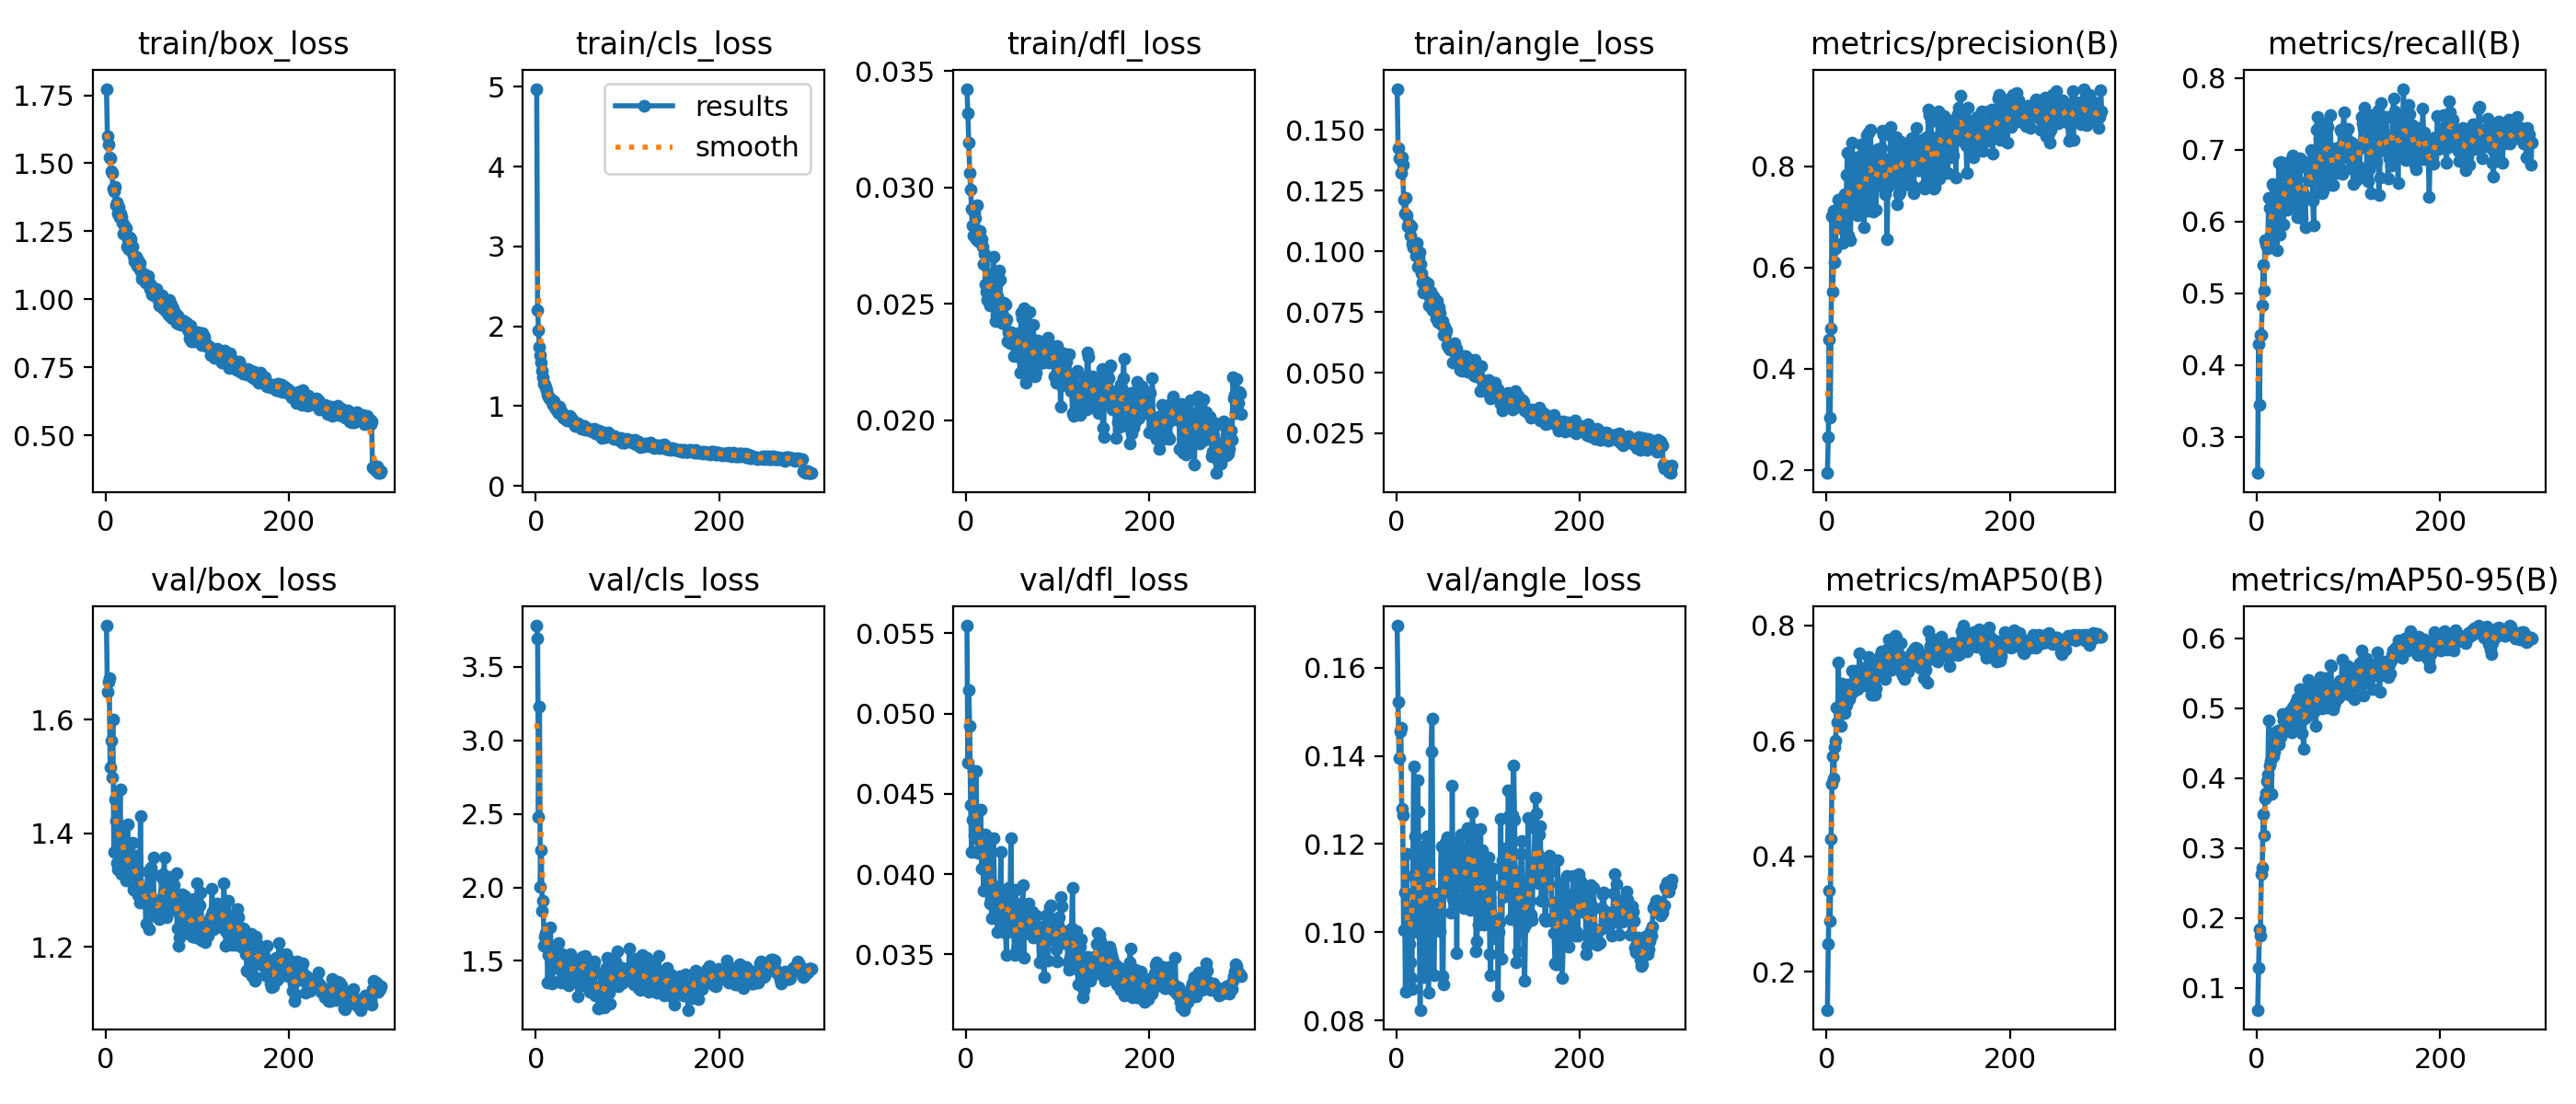


Matriz de Confusión


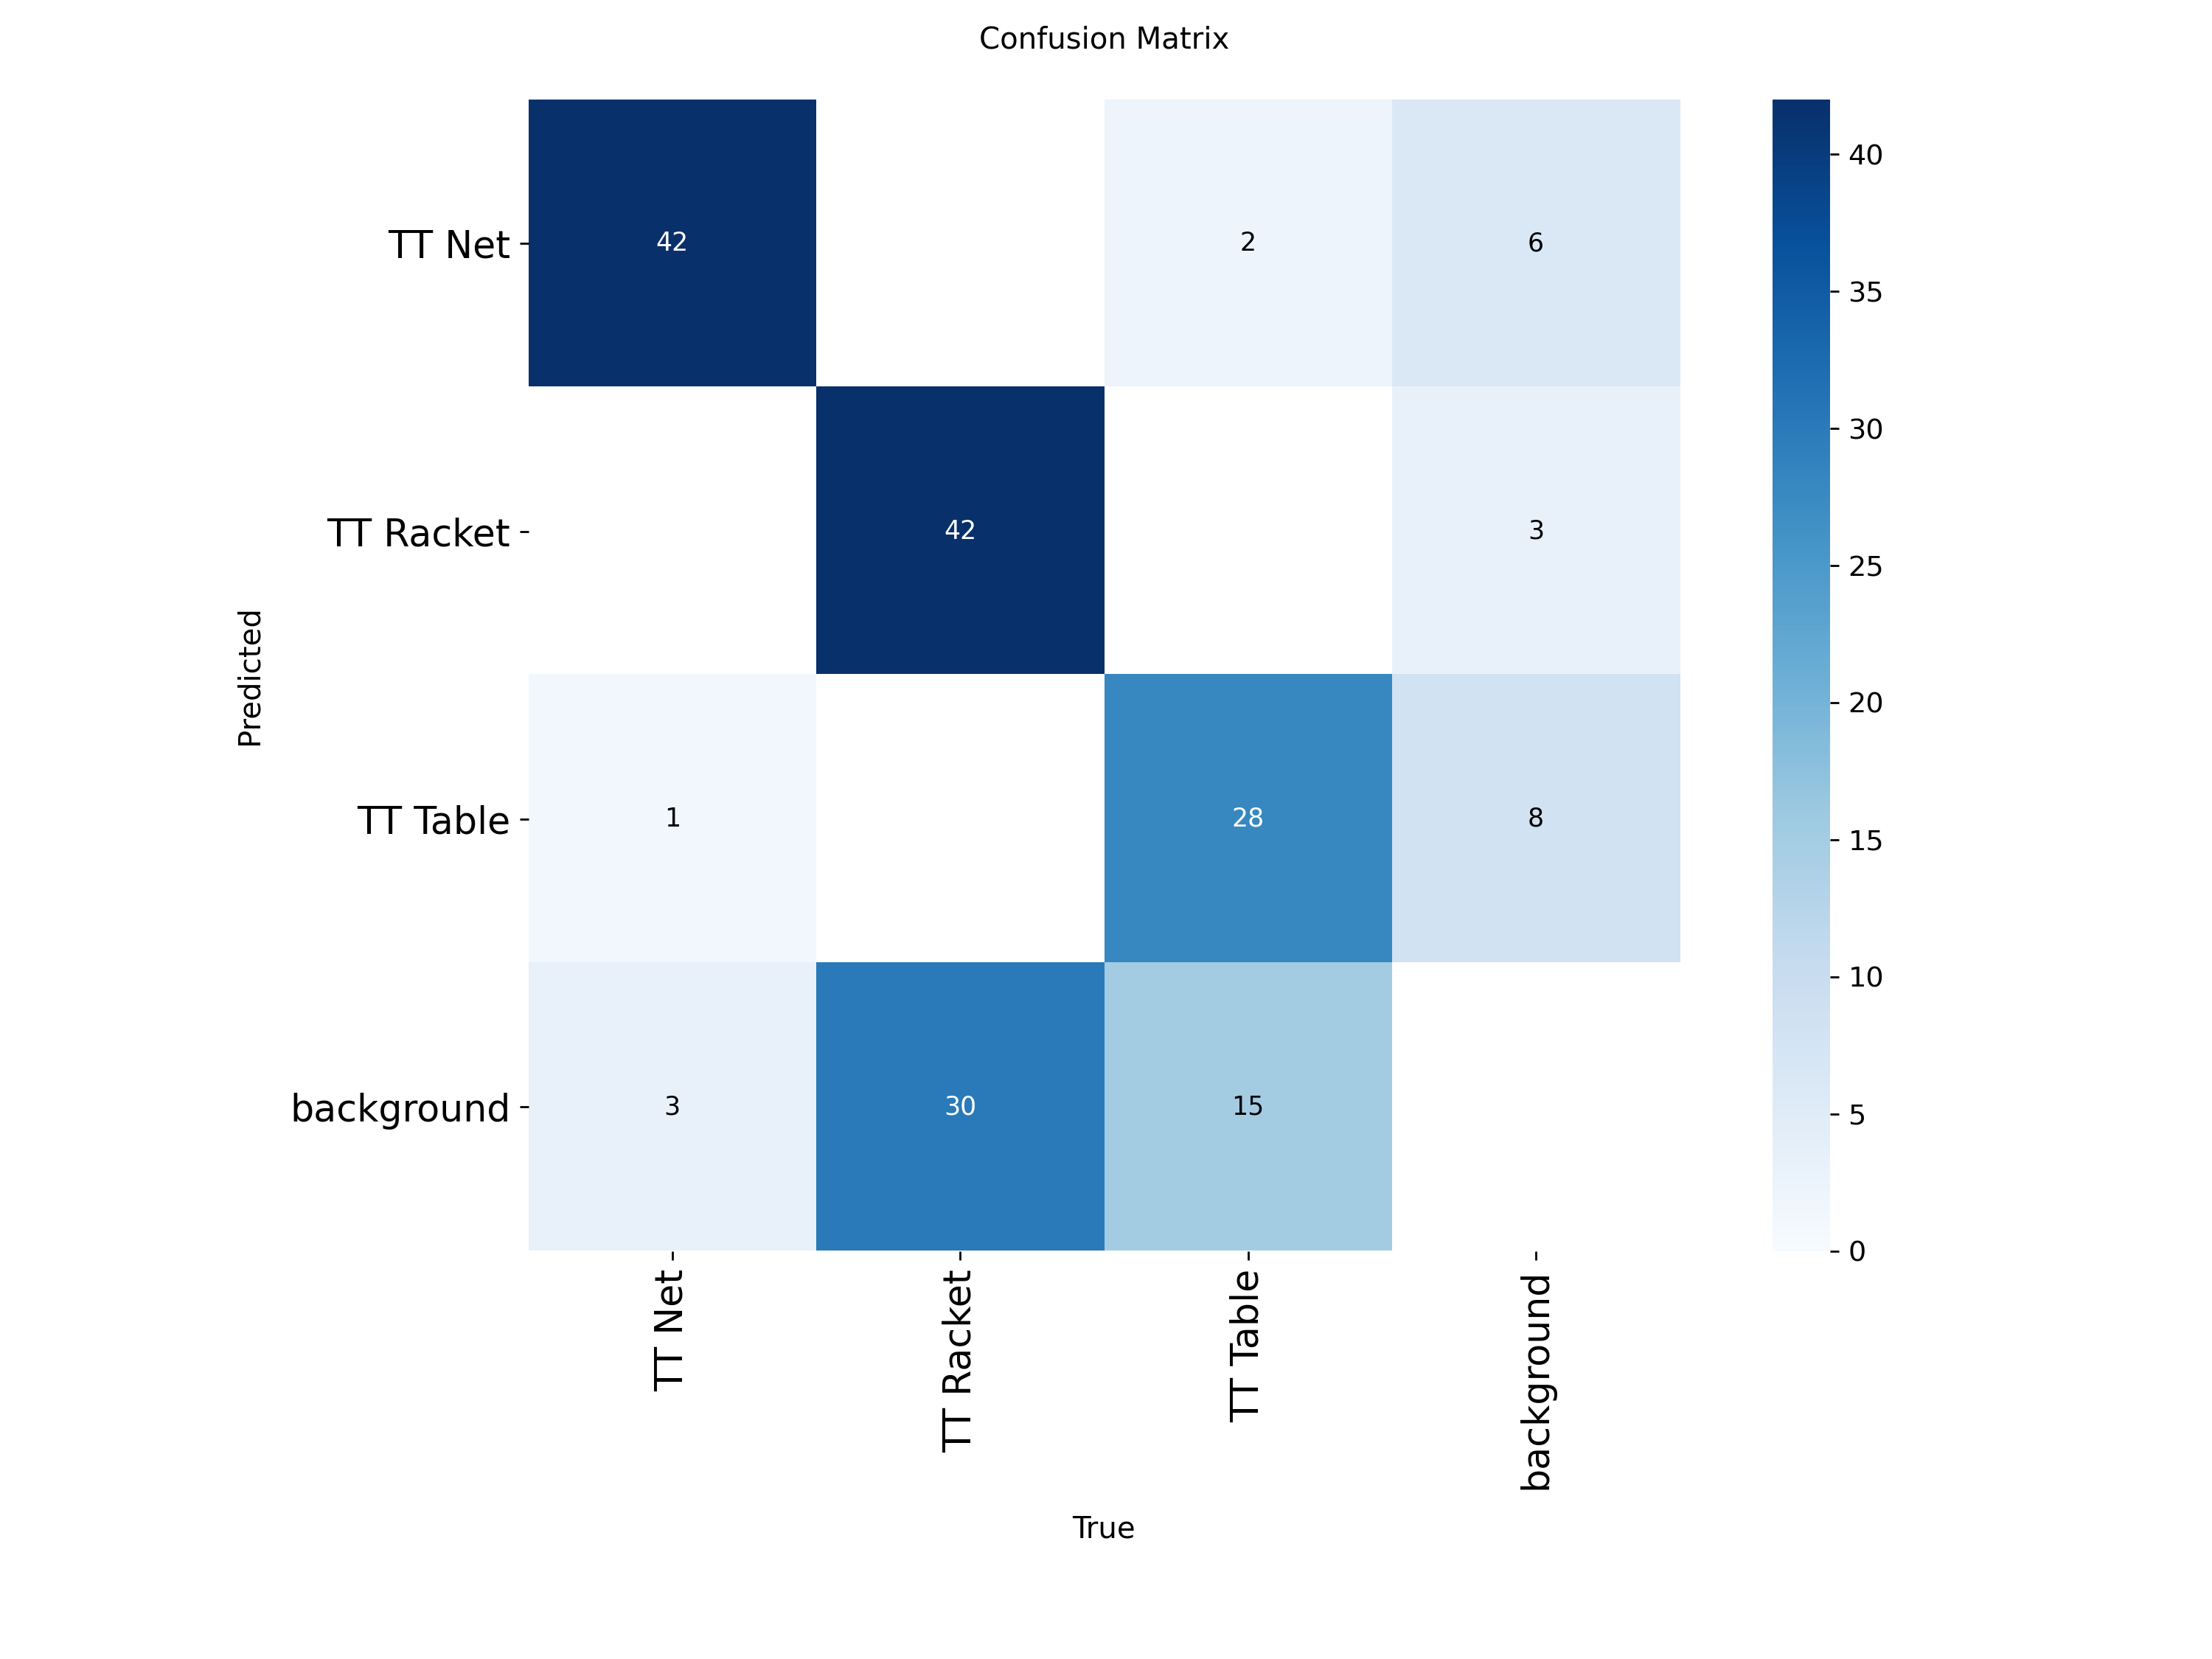

In [3]:
# Encontrar dinámicamente la carpeta del entrenamiento
results_dirs = glob.glob('**/tenis_mesa_obb_run/', recursive=True)

if results_dirs:
    results_dir = results_dirs[0]
    print(f"Cargando resultados de la carpeta: {results_dir}")

    # 1. Mostrar gráfico de pérdidas y métricas del entrenamiento
    results_png = os.path.join(results_dir, 'results.png')
    if os.path.exists(results_png):
        print("Curvas de Pérdidas y Métricas (mAP50 / mAP50-95)")
        display(Image(filename=results_png, width=800))
    else:
        print("No se encontró results.png en el directorio de resultados.")

    # 2. Mostrar la Matriz de Confusión
    confusion_matrix_png = os.path.join(results_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_matrix_png):
        print("\nMatriz de Confusión")
        display(Image(filename=confusion_matrix_png, width=600))
    else:
        print("No se encontró la matriz de confusión.")
else:
    print("ERROR: No se encontró la carpeta del entrenamiento tenis_mesa_obb_run.")

### 4. Realizar Predicciones en Imágenes de Testeo (Inferencia OBB)
Hacemos predicciones en algunas imágenes del conjunto de testeo para visualizar cómo el modelo detecta y orienta las cajas de tenis de mesa (red, raqueta, mesa).

In [4]:
import cv2
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

img_dir = '../data/dataset_obb/test/images'
weights_dir = './runs/runs/tenis_mesa_obb_run/weights/best.pt'  

class_names = {0: 'TT Net', 1: 'TT Racket', 2: 'TT Table'}
colors = ['#00b4d8', '#fcbf49', '#ff006e']

# Umbrales de confianza personalizados por clase.
conf_thresholds = {
    0: 0.25,  # TT Net    
    1: 0.12,  # TT Racket 
    2: 0.18,  # TT Table  
}

test_images = glob.glob(os.path.join(img_dir, '*.png')) + \
    glob.glob(os.path.join(img_dir, '*.jpg')) + \
    glob.glob(os.path.join(img_dir, '*.jpeg'))

if os.path.exists(weights_dir) and test_images:
    print(f"Cargando mejor modelo desde: {weights_dir}")
    print(f"Se encontraron {len(test_images)} imágenes de prueba.")
    model = YOLO(weights_dir)

    sample_images = random.sample(test_images, min(6, len(test_images)))
    print(f"Procesando inferencia en lote para {len(sample_images)} imágenes...")

    min_conf = min(conf_thresholds.values())

    predictions = model.predict(
        source=sample_images,
        conf=min_conf,
        iou=0.45,
        imgsz=960,   
        save=False
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes_flat = axes.flatten()

    for idx, (ax, result) in enumerate(zip(axes_flat, predictions)):
        img = cv2.cvtColor(result.orig_img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)

        cant_detecciones = 0
        if result.obb is not None and len(result.obb) > 0:
            for obb in result.obb:
                cid = int(obb.cls[0])
                conf = float(obb.conf[0])

                # Filtro de umbral personalizado por clase
                if conf < conf_thresholds.get(cid, 0.25):
                    continue

                cant_detecciones += 1
                c = colors[cid % len(colors)]
                polygon_pts = obb.xyxyxyxy[0].cpu().numpy()
                ax.add_patch(MplPolygon(polygon_pts, closed=True,
                             edgecolor=c, facecolor=c, alpha=0.25, lw=1.5))
                x_min, y_min = polygon_pts.min(axis=0)
                ax.text(x_min, y_min - 4, f"{class_names[cid]} {conf:.2f}",
                        color='white', fontsize=7, fontweight='bold',
                        bbox=dict(facecolor=c, pad=1, edgecolor='none'))

        ax.set_title(f"{cant_detecciones} detección(es)", fontsize=9, fontweight='semibold')
        ax.axis('off')

    for i in range(len(predictions), len(axes_flat)):
        axes_flat[i].axis('off')

    plt.suptitle('Resultados de inferencia OBB — Umbrales por clase (yolo26m-obb)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("sample_predictions_obb_custom_conf.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Gráfica generada y guardada como 'sample_predictions_obb_custom_conf.png'.")
else:
    if not os.path.exists(weights_dir):
        print(f"ERROR: No existe el archivo de pesos en la ruta: {weights_dir}")
    if not test_images:
        print(f"ERROR: No se encontraron imágenes en la ruta: {img_dir}")

Cargando mejor modelo desde: ./runs/runs/tenis_mesa_obb_run/weights/best.pt
Se encontraron 27 imágenes de prueba.
Procesando inferencia en lote para 6 imágenes...

image 1/6 /teamspace/studios/this_studio/table-tennis-cv/notebooks/../data/dataset_obb/test/images/images-76-_jpg.rf.d7d25a65364cee397f990940ab159b3b.jpg: 960x960 1 TT Net, 1 TT Racket, 1 TT Table, 9.5ms
image 2/6 /teamspace/studios/this_studio/table-tennis-cv/notebooks/../data/dataset_obb/test/images/images-2026-06-19T231847-430_jpg.rf.8da3285259a552e566f2489c3bf300cc.jpg: 960x960 1 TT Net, 1 TT Racket, 3 TT Tables, 10.0ms
image 3/6 /teamspace/studios/this_studio/table-tennis-cv/notebooks/../data/dataset_obb/test/images/suggested-BISqeGZerhKGpuy6wEJp_jpg.rf.e936e2c2676b0ac15666cc8e997ecece.jpg: 960x960 3 TT Nets, 1 TT Racket, 3 TT Tables, 9.4ms
image 4/6 /teamspace/studios/this_studio/table-tennis-cv/notebooks/../data/dataset_obb/test/images/images-52-_jpg.rf.1eecb6ab5a3d8f03a75328fd1767d6a8.jpg: 960x960 1 TT Net, 1 TT Tabl

<Figure size 1500x1000 with 6 Axes>

Gráfica generada y guardada como 'sample_predictions_obb_custom_conf.png'.
